Week & tutorial

Step 1: Load, Preprocess & Add Noise

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


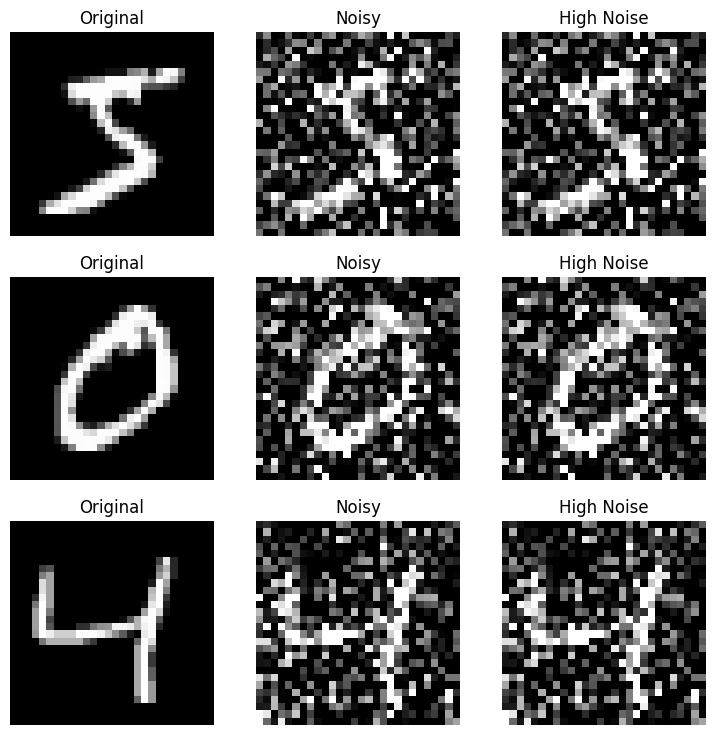

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

# Load dataset
(x_train, _), (x_test, _) = mnist.load_data()

# Normalize (0–1)
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# Reshape (28x28x1)
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

# Add noise
noise_factor = 0.5
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

# Clip values (0–1)
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

# Visualize
n = 3
plt.figure(figsize=(9, 9))
for i in range(n):
    # original
    plt.subplot(n, 3, i*3+1)
    plt.imshow(x_train[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # noisy
    plt.subplot(n, 3, i*3+2)
    plt.imshow(x_train_noisy[i].reshape(28,28), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    # more noisy
    plt.subplot(n, 3, i*3+3)
    plt.imshow(x_train_noisy[i].reshape(28,28), cmap='gray')
    plt.title("High Noise")
    plt.axis('off')

plt.show()

Step 2: Build Autoencoder Model

In [2]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Encoder
input_img = Input(shape=(28,28,1))

x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2,2), padding='same')(x)

# Decoder
x = Conv2D(64, (3,3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2,2))(x)

x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)

decoded = Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)

# Model
autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer=Adam(), loss='binary_crossentropy')

# Summary
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

Step 3: Train Model

In [3]:
history = autoencoder.fit(
    x_train_noisy, x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 176s 370ms/step - loss: 0.1580 - val_loss: 0.1115
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 197s 358ms/step - loss: 0.1084 - val_loss: 0.1047
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 169s 361ms/step - loss: 0.1034 - val_loss: 0.1009
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 202s 360ms/step - loss: 0.1007 - val_loss: 0.0991
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 169s 359ms/step - loss: 0.0991 - val_loss: 0.0977
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 164s 349ms/step - loss: 0.0979 - val_loss: 0.0969
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 169s 360ms/step - loss: 0.0971 - val_loss: 0.0966
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 166s 353ms/step - loss: 0.0965 - val_loss: 0.0959
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 206s 361ms/step - loss: 0.0959 - val_loss: 0.0957
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 164s 350ms/step - loss: 0.0954 - val_loss: 0.0946


Step 4: Evaluate & Visualize Output

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step


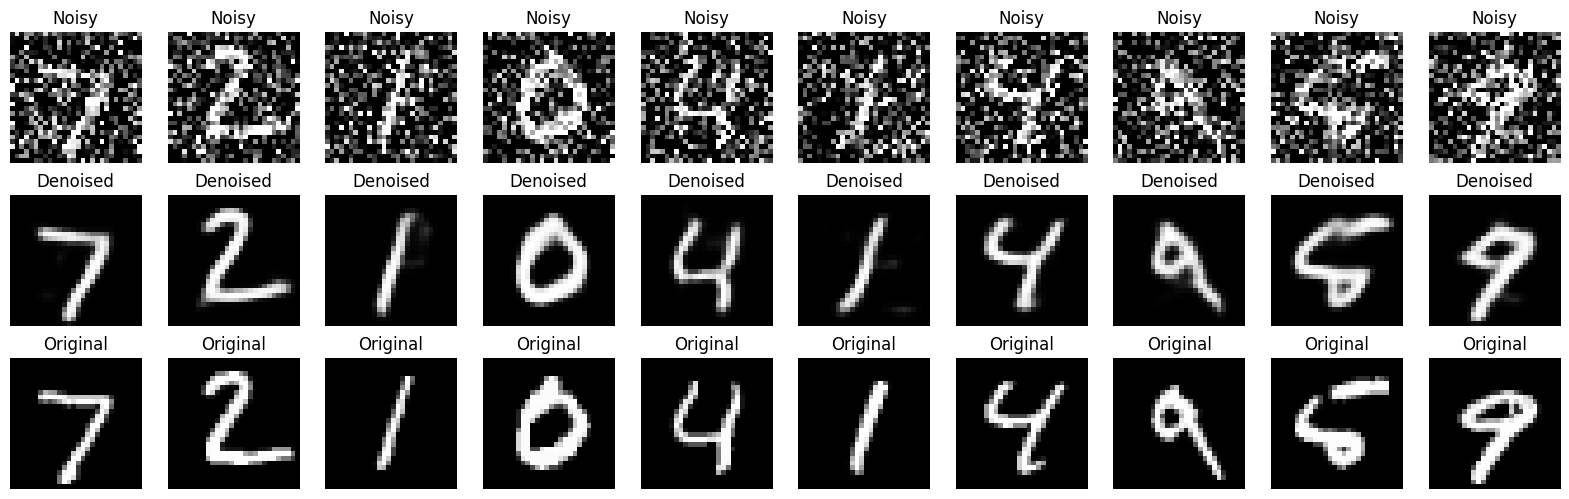

In [5]:
# Predict denoised images
denoised_images = autoencoder.predict(x_test_noisy)

# Plot results
n = 10
plt.figure(figsize=(20,6))

for i in range(n):
    # Noisy
    plt.subplot(3, n, i+1)
    plt.imshow(x_test_noisy[i].reshape(28,28), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    # Denoised
    plt.subplot(3, n, i+n+1)
    plt.imshow(denoised_images[i].reshape(28,28), cmap='gray')
    plt.title("Denoised")
    plt.axis('off')

    # Original
    plt.subplot(3, n, i+2*n+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

plt.show()